# Load Train Test Data

In [1]:
import pandas as pd
import numpy as np
np.random.seed(42)


X_train = pd.read_csv("../data/X_train.csv")
X_test  = pd.read_csv("../data/X_test.csv")
y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/y_test.csv").squeeze()


# Check Class Imbalance

In [2]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))


target
0    131
1    111
Name: count, dtype: int64
target
0    0.541322
1    0.458678
Name: proportion, dtype: float64


# Apply SMOTE

In [3]:
!pip install imbalanced-learn

  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached sklearn_compat-0.1.5-py3-none-any.whl.metadata (20 kB)
Using cached imbalanced_learn-0.14.1-py3-none-any.whl (235 kB)
Using cached sklearn_compat-0.1.5-py3-none-any.whl (20 kB)

   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]



In [4]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


# Check Balance Again

In [5]:
print(y_train_smote.value_counts())

target
1    131
0    131
Name: count, dtype: int64


In [6]:
from collections import Counter
import matplotlib.pyplot as plt

# ================= BEFORE SMOTE =================
counter_before = Counter(y_train)

plt.figure(figsize=(6,4))
plt.bar(counter_before.keys(), counter_before.values())
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.savefig("before_smote.png", dpi=300)
plt.show()


# ================= APPLY SMOTE =================
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


# ================= AFTER SMOTE =================
counter_after = Counter(y_train_smote)

plt.figure(figsize=(6,4))
plt.bar(counter_after.keys(), counter_after.values())
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.savefig("after_smote.png", dpi=300)
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

# MODEL TRAINING

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, f1_score


In [ ]:
results = []


# Create Evaluation Function

In [ ]:
def evaluate_model(name, y_test, y_pred, y_prob):

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    rec = recall_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)

    print("Model:", name)
    print("Accuracy:", acc)
    print("ROC-AUC:", roc)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("---------------------------")

    return [name, acc, roc, rec, f1]

# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_smote, y_train_smote)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

results.append(
    evaluate_model("Logistic Regression", y_test, y_pred_log, y_prob_log)
)


Model: Logistic Regression
Accuracy: 0.8688524590163934
ROC-AUC: 0.9577922077922079
Recall: 0.9285714285714286
F1 Score: 0.8666666666666667
---------------------------


# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train_smote, y_train_smote)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

results.append(
    evaluate_model("Decision Tree", y_test, y_pred_dt, y_prob_dt)
)


Model: Decision Tree
Accuracy: 0.7868852459016393
ROC-AUC: 0.7976190476190477
Recall: 0.9285714285714286
F1 Score: 0.8
---------------------------


# Random forest

In [ ]:

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=1000,random_state=42)
rf_model.fit(X_train_smote, y_train_smote)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

results.append(
    evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)
)


Model: Random Forest
Accuracy: 0.8852459016393442
ROC-AUC: 0.9556277056277056
Recall: 0.9642857142857143
F1 Score: 0.8852459016393442
---------------------------


# 4. KNN

In [ ]:

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
knn_model.fit(X_train_smote, y_train_smote)

y_pred_knn = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:,1]

results.append(
    evaluate_model("KNN", y_test, y_pred_knn, y_prob_knn)
)

Model: KNN
Accuracy: 0.7213114754098361
ROC-AUC: 0.7683982683982684
Recall: 0.6785714285714286
F1 Score: 0.6909090909090909
---------------------------


# 5. SVM

In [ ]:

from sklearn.svm import SVC

svm_model = SVC(probability=True)
svm_model.fit(X_train_smote, y_train_smote)

y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:,1]

results.append(
    evaluate_model("SVM", y_test, y_pred_svm, y_prob_svm)
)

Model: SVM
Accuracy: 0.7377049180327869
ROC-AUC: 0.7900432900432901
Recall: 0.6785714285714286
F1 Score: 0.7037037037037037
---------------------------


#  6. Gradient Boosting

In [ ]:

from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier()
gb_model.fit(X_train_smote, y_train_smote)

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:,1]

results.append(
    evaluate_model("Gradient Boosting", y_test, y_pred_gb, y_prob_gb)
)

Model: Gradient Boosting
Accuracy: 0.8688524590163934
ROC-AUC: 0.9502164502164503
Recall: 0.9642857142857143
F1 Score: 0.8709677419354839
---------------------------


#  7. XGBoost

In [ ]:

from xgboost import XGBClassifier

xgb_model = XGBClassifier(eval_metric='logloss')
xgb_model.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

results.append(
    evaluate_model("XGBoost", y_test, y_pred_xgb, y_prob_xgb)
)

Model: XGBoost
Accuracy: 0.8360655737704918
ROC-AUC: 0.9274891774891775
Recall: 0.9642857142857143
F1 Score: 0.84375
---------------------------


#  8. AdaBoost

In [ ]:

from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier()
ada_model.fit(X_train_smote, y_train_smote)

y_pred_ada = ada_model.predict(X_test)
y_prob_ada = ada_model.predict_proba(X_test)[:,1]

results.append(
    evaluate_model("AdaBoost", y_test, y_pred_ada, y_prob_ada)
)

Model: AdaBoost
Accuracy: 0.8852459016393442
ROC-AUC: 0.9653679653679654
Recall: 0.9285714285714286
F1 Score: 0.8813559322033898
---------------------------


#  9. LightGBM 

In [ ]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier()

lgbm_model.fit(X_train_smote, y_train_smote)

y_pred_lgb = lgbm_model.predict(X_test)
y_prob_lgb = lgbm_model.predict_proba(X_test)[:,1]

results.append(
    evaluate_model("LightGBM", y_test, y_pred_lgb, y_prob_lgb)
)


ModuleNotFoundError: No module named 'lightgbm'

#  FINAL MODEL COMPARISON TABLE

In [ ]:
results_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","ROC-AUC","Recall","F1-Score"]
)

# Sort based on ROC-AUC
results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

# RESET INDEX
results_df = results_df.reset_index(drop=True)

results_df


,Model,Accuracy,ROC-AUC,Recall,F1-Score
0,AdaBoost,0.885246,0.965368,0.928571,0.881356
1,Logistic Regression,0.868852,0.957792,0.928571,0.866667
2,Random Forest,0.885246,0.955628,0.964286,0.885246
3,Gradient Boosting,0.868852,0.950216,0.964286,0.870968
4,XGBoost,0.836066,0.927489,0.964286,0.843750
5,Decision Tree,0.786885,0.797619,0.928571,0.800000
6,SVM,0.737705,0.790043,0.678571,0.703704
7,KNN,0.721311,0.768398,0.678571,0.690909


# model comparision 

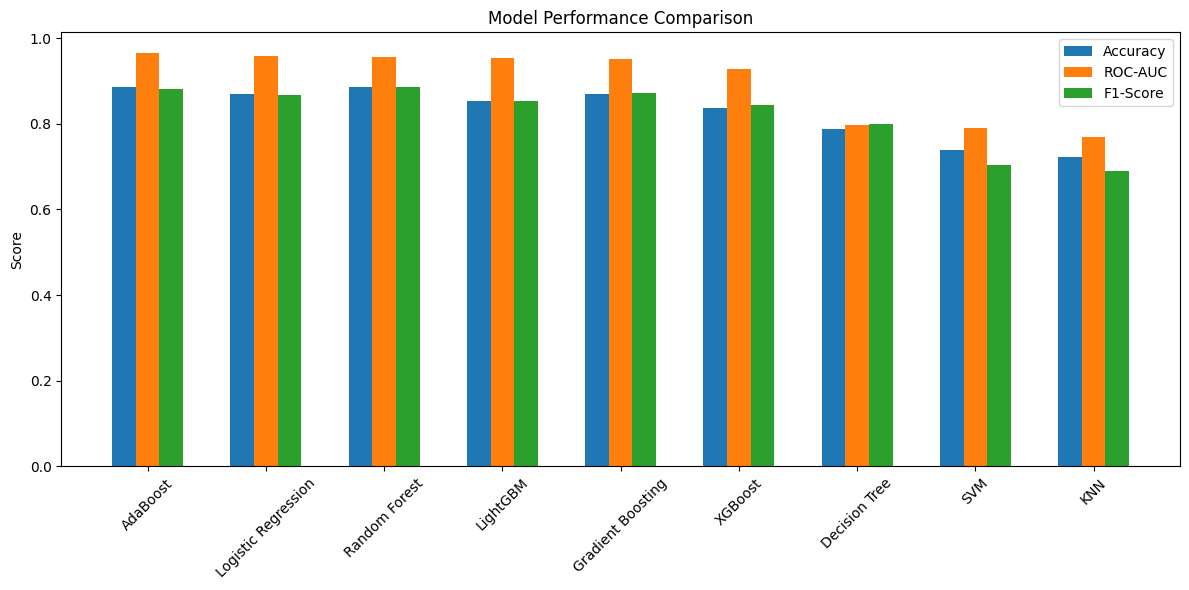

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Your final results (use your actual values)
data = {
    'Model': ['AdaBoost','Logistic Regression','Random Forest','LightGBM',
              'Gradient Boosting','XGBoost','Decision Tree','SVM','KNN'],
    
    'Accuracy': [0.885246,0.868852,0.885246,0.852459,
                 0.868852,0.836066,0.786885,0.737705,0.721311],
    
    'ROC-AUC': [0.965368,0.957792,0.955628,0.954545,
                0.950216,0.927489,0.797619,0.790043,0.768398],
    
    'Recall': [0.928571,0.928571,0.964286,0.928571,
               0.964286,0.964286,0.928571,0.678571,0.678571],
    
    'F1-Score': [0.881356,0.866667,0.885246,0.852459,
                 0.870968,0.843750,0.800000,0.703704,0.690909]
}

results_df = pd.DataFrame(data)

x = np.arange(len(results_df['Model']))
width = 0.2

plt.figure(figsize=(12,6))

plt.bar(x - width, results_df['Accuracy'], width, label='Accuracy')
plt.bar(x, results_df['ROC-AUC'], width, label='ROC-AUC')
plt.bar(x + width, results_df['F1-Score'], width, label='F1-Score')

plt.xticks(x, results_df['Model'], rotation=45)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.legend()

plt.tight_layout()
plt.savefig("model_comparison.png")
plt.show()

In [ ]:

import sys
!{sys.executable} -m pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable
  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier()

lgbm_model.fit(X_train_smote, y_train_smote)

[LightGBM] [Info] Number of positive: 131, number of negative: 131
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000519 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 251
[LightGBM] [Info] Number of data points in the train set: 262, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


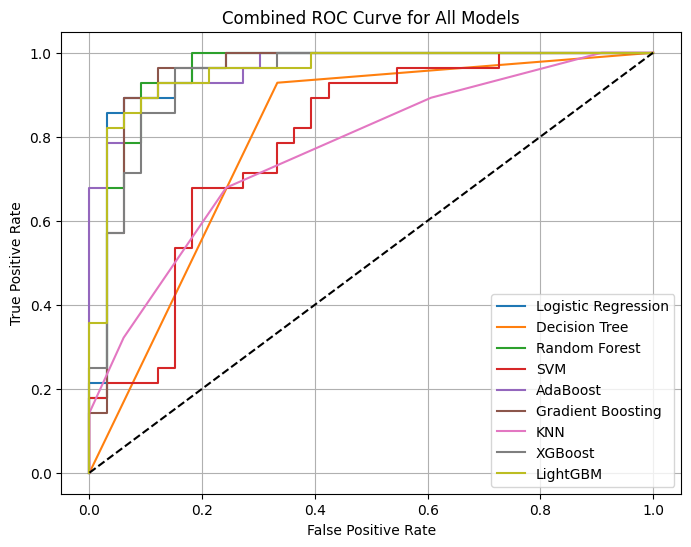

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import joblib

# LOAD TUNED MODELS
best_rf = joblib.load("../Model/best_rf_model.pkl")
best_xgb = joblib.load("../Model/best_xgb_model.pkl")

plt.figure(figsize=(8,6))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, log_model.predict_proba(X_test)[:,1])
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_model.predict_proba(X_test)[:,1])
plt.plot(fpr_dt, tpr_dt, label="Decision Tree")

# Random Forest (Tuned)
fpr_rf, tpr_rf, _ = roc_curve(y_test, best_rf.predict_proba(X_test)[:,1])
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

# SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_model.predict_proba(X_test)[:,1])
plt.plot(fpr_svm, tpr_svm, label="SVM")

# AdaBoost
fpr_ada, tpr_ada, _ = roc_curve(y_test, ada_model.predict_proba(X_test)[:,1])
plt.plot(fpr_ada, tpr_ada, label="AdaBoost")

# Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_model.predict_proba(X_test)[:,1])
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting")

# KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_model.predict_proba(X_test)[:,1])
plt.plot(fpr_knn, tpr_knn, label="KNN")

# XGBoost (Tuned)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, best_xgb.predict_proba(X_test)[:,1])
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")

# LightGBM
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, lgbm_model.predict_proba(X_test)[:,1])
plt.plot(fpr_lgbm, tpr_lgbm, label="LightGBM")

# Random Line
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Combined ROC Curve for All Models")
plt.legend()
plt.grid()

plt.savefig("combine_roc.png", dpi=300, bbox_inches='tight')
plt.show()

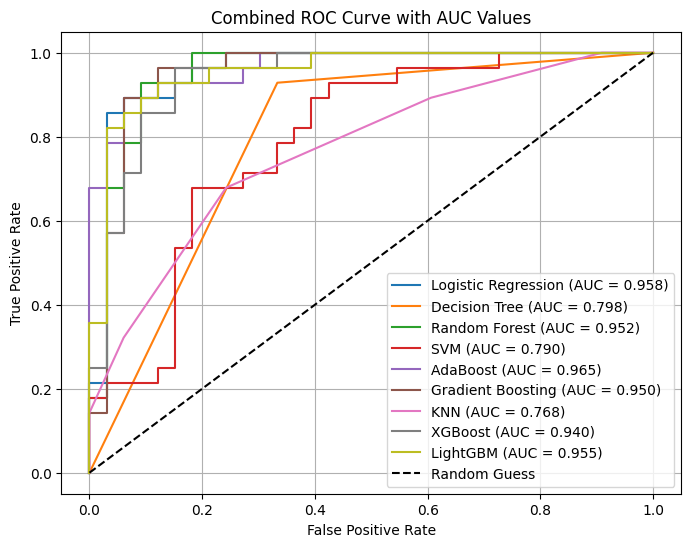

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import joblib

# LOAD TUNED MODELS
best_rf = joblib.load("../Model/best_rf_model.pkl")
best_xgb = joblib.load("../Model/best_xgb_model.pkl")

plt.figure(figsize=(8,6))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, log_model.predict_proba(X_test)[:,1])
roc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression (AUC = %0.3f)" % roc_lr)

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_model.predict_proba(X_test)[:,1])
roc_dt = auc(fpr_dt, tpr_dt)
plt.plot(fpr_dt, tpr_dt, label="Decision Tree (AUC = %0.3f)" % roc_dt)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, best_rf.predict_proba(X_test)[:,1])
roc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label="Random Forest (AUC = %0.3f)" % roc_rf)

# SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_model.predict_proba(X_test)[:,1])
roc_svm = auc(fpr_svm, tpr_svm)
plt.plot(fpr_svm, tpr_svm, label="SVM (AUC = %0.3f)" % roc_svm)

# AdaBoost
fpr_ada, tpr_ada, _ = roc_curve(y_test, ada_model.predict_proba(X_test)[:,1])
roc_ada = auc(fpr_ada, tpr_ada)
plt.plot(fpr_ada, tpr_ada, label="AdaBoost (AUC = %0.3f)" % roc_ada)

# Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_model.predict_proba(X_test)[:,1])
roc_gb = auc(fpr_gb, tpr_gb)
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting (AUC = %0.3f)" % roc_gb)

# KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_model.predict_proba(X_test)[:,1])
roc_knn = auc(fpr_knn, tpr_knn)
plt.plot(fpr_knn, tpr_knn, label="KNN (AUC = %0.3f)" % roc_knn)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, best_xgb.predict_proba(X_test)[:,1])
roc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost (AUC = %0.3f)" % roc_xgb)

# LightGBM
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, lgbm_model.predict_proba(X_test)[:,1])
roc_lgbm = auc(fpr_lgbm, tpr_lgbm)
plt.plot(fpr_lgbm, tpr_lgbm, label="LightGBM (AUC = %0.3f)" % roc_lgbm)

# Random Guess Line
plt.plot([0,1],[0,1],'k--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Combined ROC Curve with AUC Values")
plt.legend(loc="lower right")
plt.grid()

plt.savefig("combine_roc.png", dpi=300, bbox_inches='tight')
plt.show()

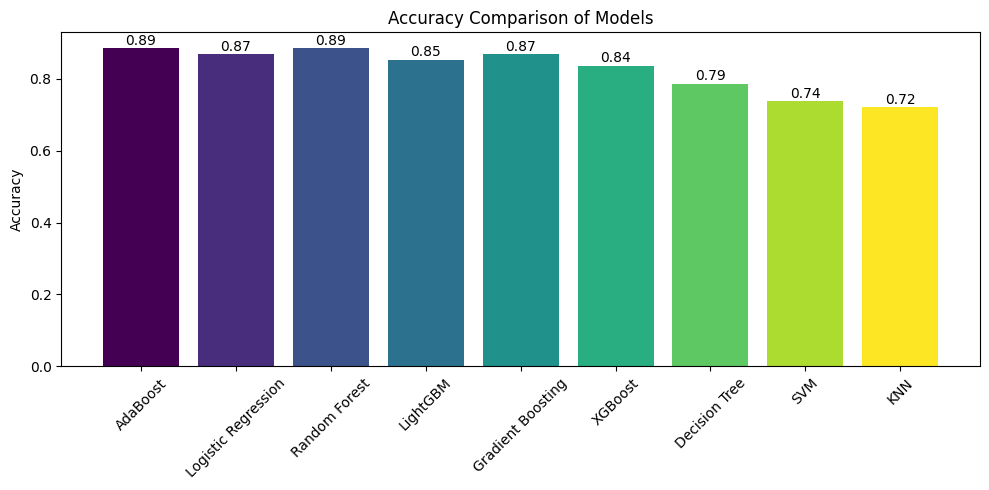

In [ ]:
plt.figure(figsize=(10,5))
colors = plt.cm.viridis(np.linspace(0,1,len(results_df)))

plt.bar(results_df['Model'], results_df['Accuracy'], color=colors)

plt.title("Accuracy Comparison of Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)

for i, v in enumerate(results_df['Accuracy']):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.savefig("accuracy_bar.png")
plt.show()

# RECALL BAR GRAPH

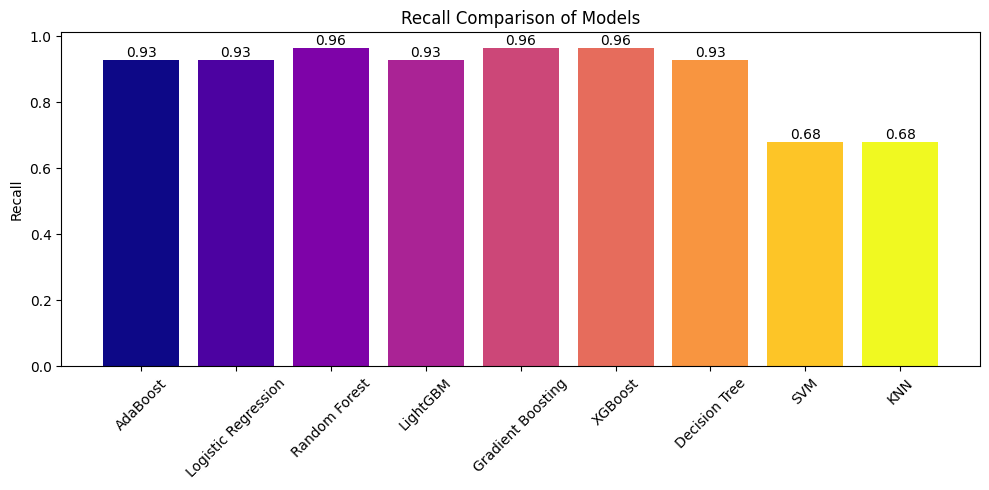

In [ ]:
plt.figure(figsize=(10,5))
colors = plt.cm.plasma(np.linspace(0,1,len(results_df)))

plt.bar(results_df['Model'], results_df['Recall'], color=colors)

plt.title("Recall Comparison of Models")
plt.ylabel("Recall")
plt.xticks(rotation=45)

for i, v in enumerate(results_df['Recall']):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.savefig("recall_bar.png")
plt.show()

# F1-Score

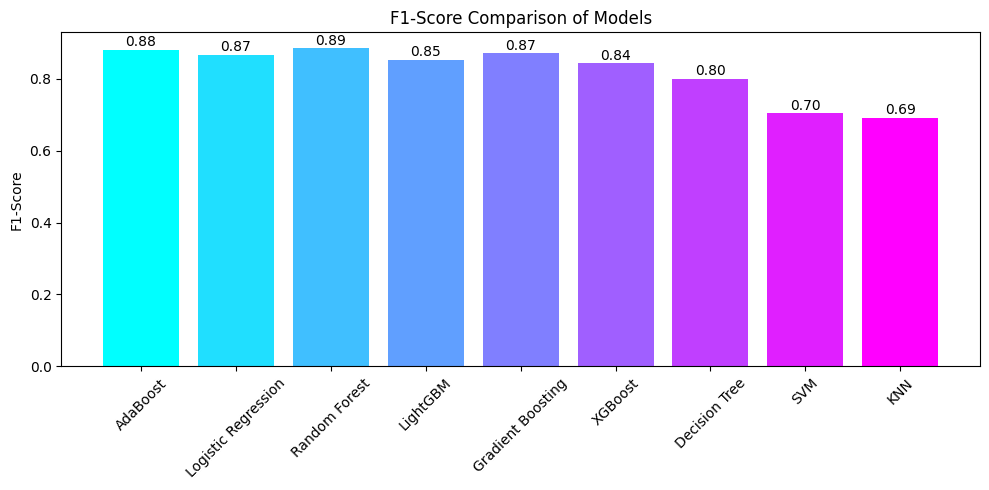

In [ ]:
plt.figure(figsize=(10,5))
colors = plt.cm.cool(np.linspace(0,1,len(results_df)))

plt.bar(results_df['Model'], results_df['F1-Score'], color=colors)

plt.title("F1-Score Comparison of Models")
plt.ylabel("F1-Score")
plt.xticks(rotation=45)

for i, v in enumerate(results_df['F1-Score']):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.savefig("f1_score_bar.png")
plt.show()

# ROC-AUC Graph

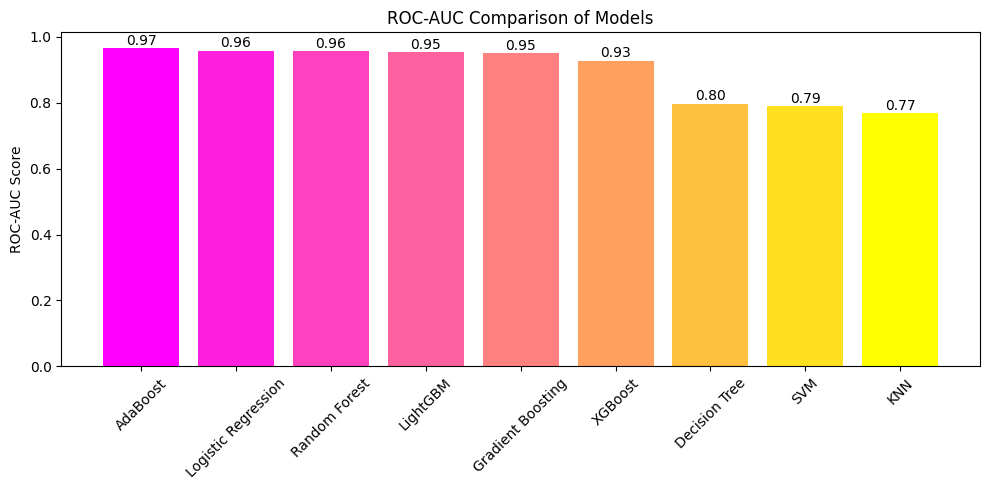

In [ ]:
plt.figure(figsize=(10,5))
colors = plt.cm.spring(np.linspace(0,1,len(results_df)))

plt.bar(results_df['Model'], results_df['ROC-AUC'], color=colors)

plt.title("ROC-AUC Comparison of Models")
plt.ylabel("ROC-AUC Score")
plt.xticks(rotation=45)

for i, v in enumerate(results_df['ROC-AUC']):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.savefig("roc_auc_bar.png")
plt.show()

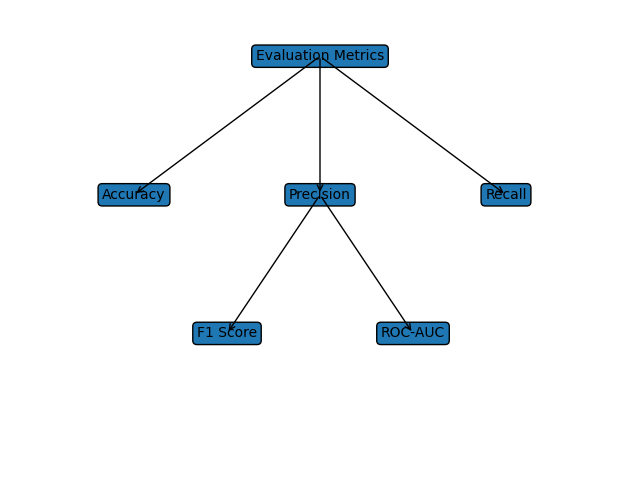

In [ ]:
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(8, 6))

# Draw text boxes (x, y positions)
boxes = {
    "Evaluation Metrics": (0.5, 0.9),
    "Accuracy": (0.2, 0.6),
    "Precision": (0.5, 0.6),
    "Recall": (0.8, 0.6),
    "F1 Score": (0.35, 0.3),
    "ROC-AUC": (0.65, 0.3)
}

# Draw boxes
for text, (x, y) in boxes.items():
    plt.text(x, y, text,
             ha='center', va='center',
             bbox=dict(boxstyle="round,pad=0.3"))

# Draw arrows
def draw_arrow(start, end):
    plt.annotate("",
                 xy=end, xytext=start,
                 arrowprops=dict(arrowstyle="->"))

# Connections
draw_arrow(boxes["Evaluation Metrics"], boxes["Accuracy"])
draw_arrow(boxes["Evaluation Metrics"], boxes["Precision"])
draw_arrow(boxes["Evaluation Metrics"], boxes["Recall"])
draw_arrow(boxes["Precision"], boxes["F1 Score"])
draw_arrow(boxes["Precision"], boxes["ROC-AUC"])

# Remove axis
plt.axis('off')

# Save figure
plt.savefig("evaluation_metrics.png", bbox_inches='tight', dpi=300)

# Show
plt.show()